In [ ]:
# This notebook compares the galaxy clustering signal wp(rp) measured on
# real DESI data (scripts/clustering/run_wgg_data.py) against the
# AbacusHOD mock catalogue (scripts/clustering/run_wgg_box.py), for the
# LRG and ELG tracers.

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM

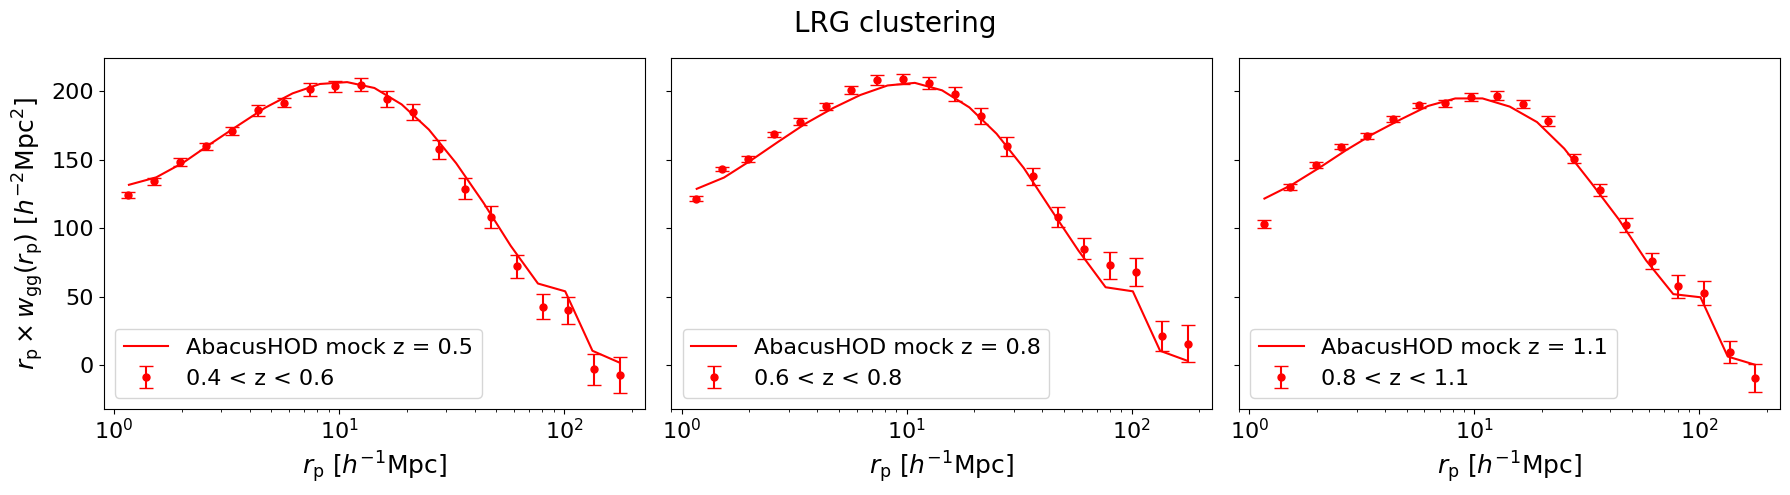

In [13]:
# --- LRG clustering: data vs mock, in three redshift bins ---
# `data_files` hold the DESI measurement + jackknife errors
# (run_wgg_data.py output), `mock_files` hold the AbacusHOD mock
# measurement (run_wgg_box.py output) at the matching simulation redshift.

# Files
data_files = [
    "/n17data/corinaldi/halos/Abacus_HOD/pycorr/results_data/wgg_LRG_z0.4_0.6_pycorr.npz",
    "/n17data/corinaldi/halos/Abacus_HOD/pycorr/results_data/wgg_LRG_z0.6_0.8_pycorr.npz",
    "/n17data/corinaldi/halos/Abacus_HOD/pycorr/results_data/wgg_LRG_z0.8_1.1_pycorr.npz"
]

mock_files = [
    "/n17data/corinaldi/halos/Abacus_HOD/pycorr/results_mock/LRG_mock_z0.5.npz",
    "/n17data/corinaldi/halos/Abacus_HOD/pycorr/results_mock/LRG_mock_z0.8.npz",
    "/n17data/corinaldi/halos/Abacus_HOD/pycorr/results_mock/LRG_mock_z1.1.npz"
]

z_bins = ['0.4 < z < 0.6', '0.6 < z < 0.8', '0.8 < z < 1.1']
snapshots = ['z = 0.5', 'z = 0.8', 'z = 1.1']

# Figure: one subplot per redshift bin, sharing the y-axis
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, ax in enumerate(axes):
    data = np.load(data_files[i])
    mock = np.load(mock_files[i])

    rp = data['rp']
    wgg = data['wgg']
    err = data['err_jk']

    # Data: rp * wp(rp) with jackknife error bars
    ax.errorbar(
        rp, rp*wgg, yerr=rp*err,
        fmt='o', markersize=5, capsize=5,
        color='red',
        label=f"{z_bins[i]}"
    )

    # Mock: rp * wp(rp) prediction from the AbacusHOD mock catalogue
    ax.plot(
        mock['rp'], mock['rp']*mock['wgg'],
        color='red',
        label=f"AbacusHOD mock {snapshots[i]}"
    )

    ax.set_xscale('log')
    ax.tick_params(axis='both', which='major', labelsize=16)

    # Per-subplot legend showing the data redshift bin / mock snapshot
    ax.legend(fontsize=16)

# Shared axis labels
axes[0].set_ylabel(r'$r_\mathrm{p} \times w_{\mathrm{gg}}(r_\mathrm{p})~[h^{-2}\mathrm{Mpc}^2]$', fontsize=18)
for ax in axes:
    ax.set_xlabel(r'$r_{\mathrm{p}}~[h^{-1}\mathrm{Mpc}]$', fontsize=18)

plt.suptitle('LRG clustering', fontsize=20)
plt.tight_layout()
plt.show()

In [ ]:
# --- ELG data: load the DESI ELG sample and convert to comoving Cartesian
# coordinates, mirroring the logic of run_wgg_data.py (kept here for
# reference/inspection rather than to recompute wp — the actual wp(rp)
# measurement is reloaded from the .npz file in the next cell).
cosmo = FlatLambdaCDM(H0=100, Om0=0.3158)

tracer = 'ELG'
zmin = 0.8; zmax = 1.6



# Data
galaxy_sample = Table.read(f'/n17data/corinaldi/DESI/clustering_data/{tracer}/{tracer}_data_NGC+SGC.fits')
galaxy_sample = galaxy_sample.to_pandas()
#galaxy_sample = galaxy_sample[(galaxy_sample['Z'] > zmin) & (galaxy_sample['Z'] < zmax)].copy()
chi = cosmo.comoving_distance(galaxy_sample['Z']).value
x_d = chi * np.cos(galaxy_sample['RA'].values * np.pi / 180) * np.cos(galaxy_sample['DEC'].values * np.pi / 180)
y_d = chi * np.sin(galaxy_sample['RA'].values * np.pi / 180) * np.cos(galaxy_sample['DEC'].values * np.pi / 180)
z_d = chi * np.sin(galaxy_sample['DEC'].values * np.pi / 180)
pos_data = np.array([x_d, y_d, z_d])
w_data = galaxy_sample['WEIGHT'] * galaxy_sample['WEIGHT_FKP']

In [ ]:
# Reload the precomputed ELG wp(rp) measurement (data + jackknife errors)
# and the corresponding AbacusHOD mock prediction at z = 1.1.
data = np.load("/n17data/corinaldi/halos/Abacus_HOD/pycorr/results_data/wgg_ELG_z0.8_1.6_pycorr.npz")
mock = np.load("/n17data/corinaldi/halos/Abacus_HOD/pycorr/results_mock/ELG_mock_z1.1.npz")

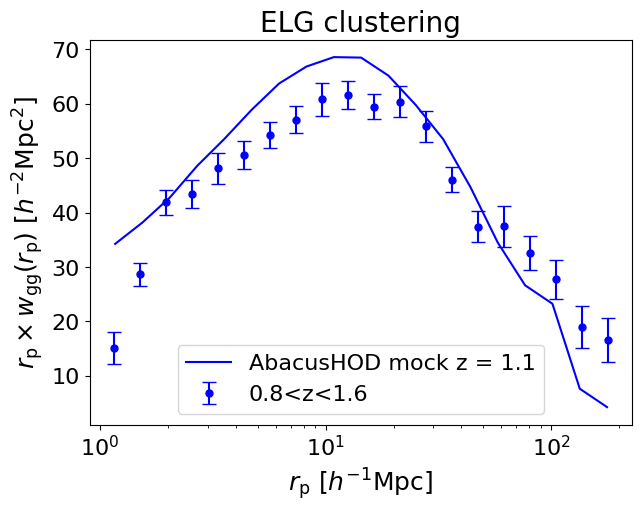

In [4]:
# --- ELG clustering: data vs mock, single redshift bin ---
plt.figure(figsize=(7,5))

# Data: rp * wp(rp) with jackknife error bars
plt.errorbar(data['rp'], data['rp']*data['wgg'], yerr=data['rp']*data['err_jk'], fmt='o', markersize=5, capsize=5, label='0.8<z<1.6', color = 'blue')
# Mock: rp * wp(rp) prediction from the AbacusHOD mock catalogue
plt.plot(mock['rp'], mock['rp']*mock['wgg'], label='AbacusHOD mock z = 1.1', color = 'blue')



plt.xscale('log')
plt.xlabel(r'$r_{\mathrm{p}}~[h^{-1}\mathrm{Mpc}]$', fontsize=18)
plt.ylabel(r'$r_\mathrm{p} \times w_{\mathrm{gg}}(r_\mathrm{p})~[h^{-2}\mathrm{Mpc}^2]$', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.legend(fontsize=16)
plt.title('ELG clustering', fontsize=20)
#plt.savefig('/n17data/corinaldi/UNIONS_3D_shapes_IA/plots_paper/ELG_clustering.pdf', bbox_inches='tight')
plt.show()